In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential, load_model
from keras.layers import Input, Dense, Flatten, Conv2D, MaxPooling2D, Dropout, BatchNormalization, GlobalAveragePooling2D
from keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize
from keras.src.legacy.preprocessing.image import ImageDataGenerator
from keras.models import Sequential

plt.style.use('default')


In [2]:
# Load the data
from keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

C:\Users\HP\PycharmProjects\DL-Labs\venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [3]:
classification = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [4]:
y_train_one_hot = to_categorical(y_train)
y_test_one_hot = to_categorical(y_test)

In [5]:
x_train = x_train / 255
x_test = x_test / 255

In [6]:
def build_model(convs=2, dense_layers=2, conv_kernel=(5,5), pool_kernel=(2, 2), dense_neurons=1000,
                loss='categorical_crossentropy', optimizer='adam', metric='accuracy', dropout_rate=0.5):

    model = Sequential()
    model.add(Input(shape=(32,32,3)))

    for conv in range(convs):
        if conv == 0:
            model.add(Conv2D(32, conv_kernel, activation='relu', padding='same'))
        else:
            model.add(Conv2D(64, conv_kernel, activation='relu', padding='same'))
        model.add(MaxPooling2D(pool_size=pool_kernel, padding='same'))

    model.add(Flatten())

    for dense in range(dense_layers):
        model.add(Dense(int(dense_neurons/(dense+1)), activation='relu'))
        model.add(Dropout(dropout_rate))

    model.add(Dense(250, activation='relu'))
    model.add(Dense(10, activation='softmax'))

    model.compile(loss=loss, optimizer=optimizer, metrics=[metric])
    return model

In [7]:
def run_experiment(model, model_title, history_dict):
    """Run experiment and store history"""
    print(f"Training {model_title}...")
    history = model.fit(x_train, y_train_one_hot,
                       validation_data=(x_test, y_test_one_hot),
                       epochs=10, batch_size=64, verbose=0)
    history_dict[model_title] = {
        'accuracy': history.history['accuracy'],
        'val_accuracy': history.history['val_accuracy'],
        'loss': history.history['loss'],
        'val_loss': history.history['val_loss']
    }
    return history

In [8]:
def plot_parameter_comparison(models_dict, parameter_name, default_model_name='Default model'):
    """Create a plot comparing models for a specific parameter"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    (ax1, ax2), (ax3, ax4) = axes

    # Plot training accuracy
    for model_name, history in models_dict.items():
        ax1.plot(history['accuracy'], label=model_name, linewidth=2)

    ax1.set_title(f'{parameter_name} - Training Accuracy Comparison', fontsize=14)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Training Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot validation accuracy
    for model_name, history in models_dict.items():
        ax2.plot(history['val_accuracy'], label=model_name, linewidth=2)

    ax2.set_title(f'{parameter_name} - Validation Accuracy Comparison', fontsize=14)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Validation Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Plot training loss
    for model_name, history in models_dict.items():
        ax3.plot(history['loss'], label=model_name, linewidth=2)

    ax3.set_title(f'{parameter_name} - Training Loss Comparison', fontsize=14)
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Training Loss')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # Plot validation loss
    for model_name, history in models_dict.items():
        ax4.plot(history['val_loss'], label=model_name, linewidth=2)

    ax4.set_title(f'{parameter_name} - Validation Loss Comparison', fontsize=14)
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Validation Loss')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [9]:
# Store all histories
all_histories = {}

In [10]:
# model_default = load_model('model_default.keras')
# model_add_convs1 = load_model('model_add_convs1.keras')
# model_add_convs2 = load_model('model_add_convs2.keras')
# model_diff_kernel1 = load_model('model_diff_kernel1.keras')
# model_diff_kernel2 = load_model('model_diff_kernel2.keras')
#
# model_diff_dropout1 = load_model('model_diff_dropout1.keras')
# model_diff_dropout2 = load_model('model_diff_dropout2.keras')
# model_diff_dense1 = load_model('model_diff_dense1.keras')
# model_diff_dense2 = load_model('model_diff_dense2.keras')
# model_diff_opt1 = load_model('model_diff_opt1.keras')
# model_diff_opt2 = load_model('model_diff_opt2.keras')

In [11]:
# Train default model first
# print("Training default model...")
default_model = build_model()
default_history = default_model.fit(x_train, y_train_one_hot, batch_size=256, epochs=10, validation_split=0.2, verbose=0)
# default_history = default_model.history
all_histories['Default model'] = {
    'accuracy': default_history.history['accuracy'],
    'val_accuracy': default_history.history['val_accuracy'],
    'loss': default_history.history['loss'],
    'val_loss': default_history.history['val_loss']
}

In [12]:
print('Test accuracy (default model):', default_model.evaluate(x_test, y_test_one_hot)[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6965 - loss: 0.9929
Test accuracy (default model): 0.6965000033378601


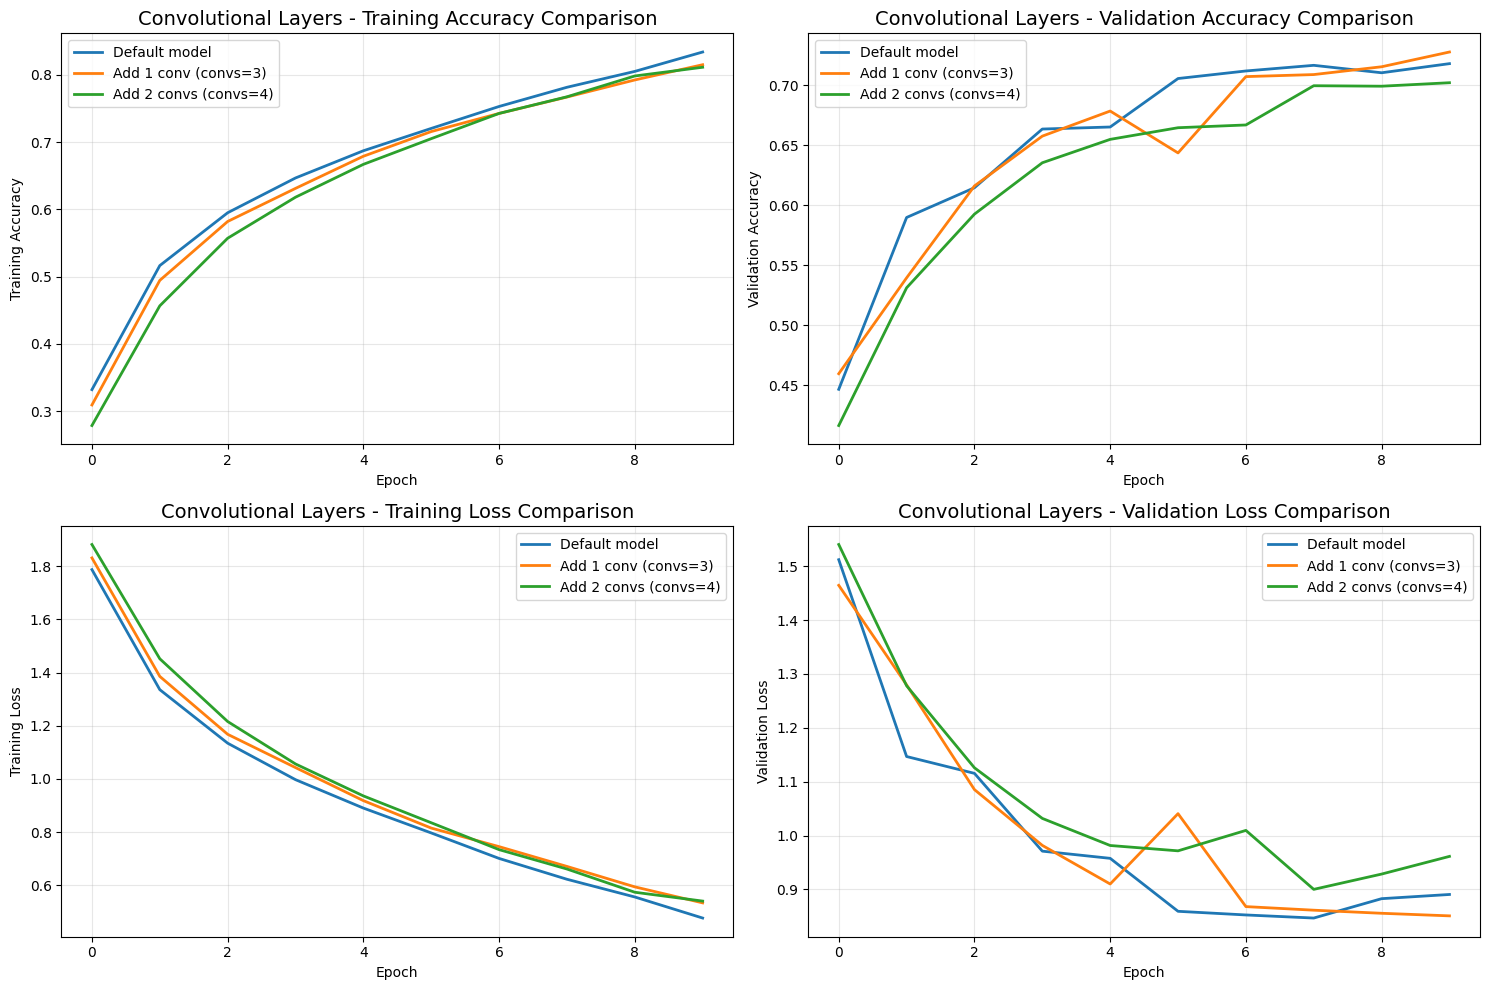

In [17]:
# 1. додати додаткові шари конволюції і пулінга
# print("\n=== Experiment 1: Additional convolution and pooling layers ===")
models_conv = {'Default model': all_histories['Default model']}

model_add_convs1 = build_model(convs=3)
model_add_convs1_history = model_add_convs1.fit(x_train, y_train_one_hot, batch_size=256, epochs=10, validation_split=0.2, verbose=0)
# model_add_convs1_history = model_add_convs1.history
models_conv['Add 1 conv (convs=3)'] = {
    'accuracy': model_add_convs1_history.history['accuracy'],
    'val_accuracy': model_add_convs1_history.history['val_accuracy'],
    'loss': model_add_convs1_history.history['loss'],
    'val_loss': model_add_convs1_history.history['val_loss']
}

model_add_convs2 = build_model(convs=4)
model_add_convs2_history = model_add_convs2.fit(x_train, y_train_one_hot, batch_size=256, epochs=10, validation_split=0.2, verbose=0)
# model_add_convs2_history = model_add_convs2.history
models_conv['Add 2 convs (convs=4)'] = {
    'accuracy': model_add_convs2_history.history['accuracy'],
    'val_accuracy': model_add_convs2_history.history['val_accuracy'],
    'loss': model_add_convs2_history.history['loss'],
    'val_loss': model_add_convs2_history.history['val_loss']
}

plot_parameter_comparison(models_conv, 'Convolutional Layers')


In [18]:
print('Test accuracy (+1 conv):', model_add_convs1.evaluate(x_test, y_test_one_hot)[1])
print('Test accuracy (+2 conv):', model_add_convs2.evaluate(x_test, y_test_one_hot)[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7197 - loss: 0.8846
Test accuracy (+1 conv): 0.7196999788284302
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7003 - loss: 0.9646
Test accuracy (+2 conv): 0.7002999782562256


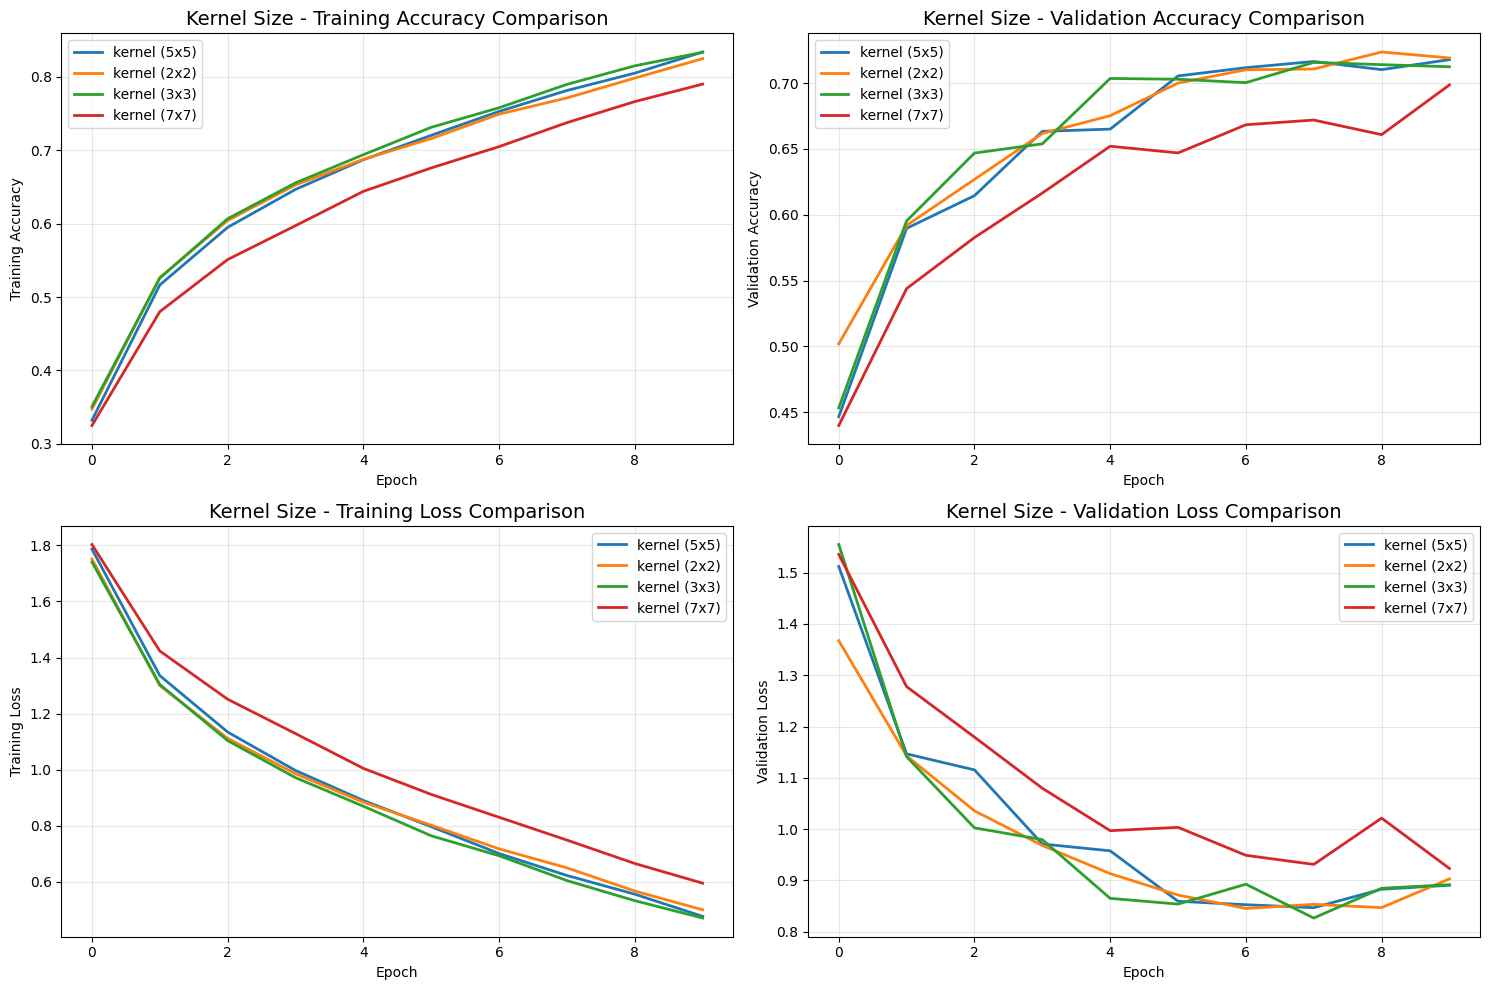

In [33]:
# 2. поміняти параметри ядер
# print("\n=== Experiment 2: Kernel size ===")
models_kernel = {'kernel (5x5)': all_histories['Default model']}

model_diff_kernel1 = build_model(convs=2, conv_kernel=(3,3))
model_diff_kernel1_history = model_diff_kernel1.fit(x_train, y_train_one_hot, batch_size=256, epochs=10, validation_split=0.2, verbose=0)
# model_diff_kernel1_history = model_diff_kernel1.history
models_kernel['kernel (2x2)'] = {
    'accuracy': model_diff_kernel1_history.history['accuracy'],
    'val_accuracy': model_diff_kernel1_history.history['val_accuracy'],
    'loss': model_diff_kernel1_history.history['loss'],
    'val_loss': model_diff_kernel1_history.history['val_loss']
}

model_diff_kernel2 = build_model(convs=2, conv_kernel=(5,5))
model_diff_kernel2_history = model_diff_kernel2.fit(x_train, y_train_one_hot, batch_size=256, epochs=10, validation_split=0.2, verbose=0)
# model_diff_kernel2_history = model_diff_kernel2.history
models_kernel['kernel (3x3)'] = {
    'accuracy': model_diff_kernel2_history.history['accuracy'],
    'val_accuracy': model_diff_kernel2_history.history['val_accuracy'],
    'loss': model_diff_kernel2_history.history['loss'],
    'val_loss': model_diff_kernel2_history.history['val_loss']
}

model_diff_kernel3 = build_model(convs=2, conv_kernel=(7,7))
model_diff_kernel3_history = model_diff_kernel3.fit(x_train, y_train_one_hot, batch_size=256, epochs=10, validation_split=0.2, verbose=0)
models_kernel['kernel (7x7)'] = {
    'accuracy': model_diff_kernel3_history.history['accuracy'],
    'val_accuracy': model_diff_kernel3_history.history['val_accuracy'],
    'loss': model_diff_kernel3_history.history['loss'],
    'val_loss': model_diff_kernel3_history.history['val_loss']
}

plot_parameter_comparison(models_kernel, 'Kernel Size')

In [34]:
print('Test accuracy (kernel 2x2):', model_diff_kernel1.evaluate(x_test, y_test_one_hot)[1])
print('Test accuracy (kernel 3x3):', model_diff_kernel2.evaluate(x_test, y_test_one_hot)[1])
print('Test accuracy (kernel 7x7):', model_diff_kernel3.evaluate(x_test, y_test_one_hot)[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7144 - loss: 0.9126
Test accuracy (kernel 2x2): 0.7143999934196472
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7082 - loss: 0.9205
Test accuracy (kernel 3x3): 0.7081999778747559
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6888 - loss: 0.9526
Test accuracy (kernel 7x7): 0.6887999773025513


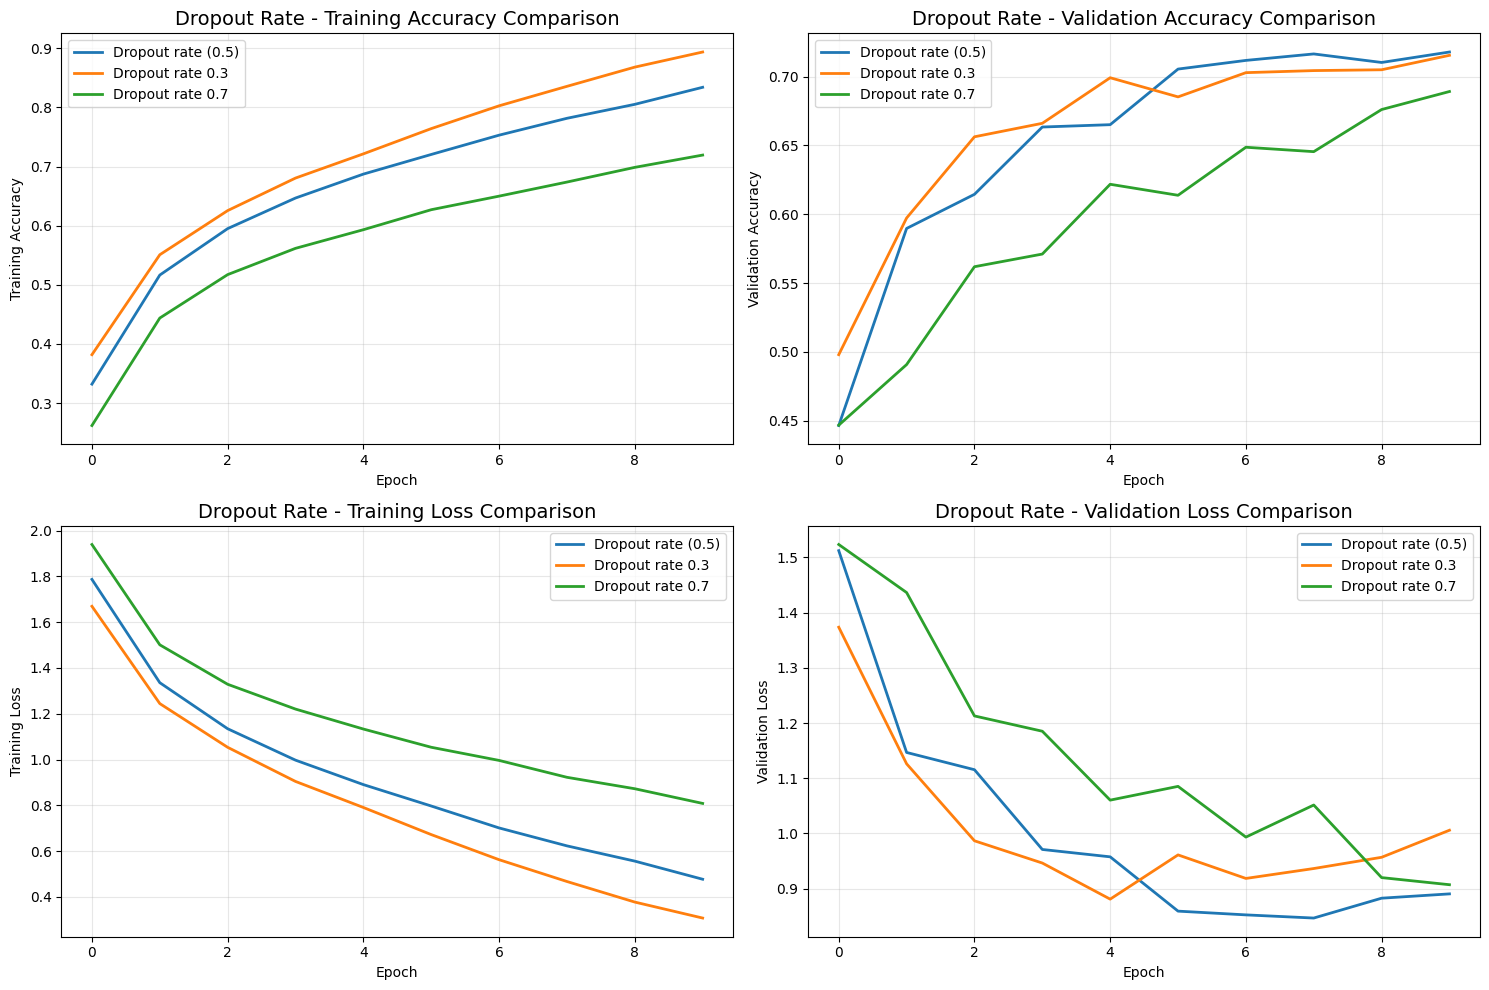

In [21]:
# 3. змінити параметри шарів Dropout
# print("\n=== Experiment 3: Dropout rate ===")
models_dropout = {'Dropout rate (0.5)': all_histories['Default model']}

model_diff_dropout1 = build_model(dropout_rate=0.3)
model_diff_dropout1_history = model_diff_dropout1.fit(x_train, y_train_one_hot, batch_size=256, epochs=10, validation_split=0.2, verbose=0)
# model_diff_dropout1_history = model_diff_dropout1.history
models_dropout['Dropout rate 0.3'] = {
    'accuracy': model_diff_dropout1_history.history['accuracy'],
    'val_accuracy': model_diff_dropout1_history.history['val_accuracy'],
    'loss': model_diff_dropout1_history.history['loss'],
    'val_loss': model_diff_dropout1_history.history['val_loss']
}

model_diff_dropout2 = build_model(dropout_rate=0.7)
model_diff_dropout2_history = model_diff_dropout2.fit(x_train, y_train_one_hot, batch_size=256, epochs=10, validation_split=0.2, verbose=0)
# model_diff_dropout2_history = model_diff_dropout2.history
models_dropout['Dropout rate 0.7'] = {
    'accuracy': model_diff_dropout2_history.history['accuracy'],
    'val_accuracy': model_diff_dropout2_history.history['val_accuracy'],
    'loss': model_diff_dropout2_history.history['loss'],
    'val_loss': model_diff_dropout2_history.history['val_loss']
}

plot_parameter_comparison(models_dropout, 'Dropout Rate')


In [22]:
print('Test accuracy (dropout 0.2):', model_diff_dropout1.evaluate(x_test, y_test_one_hot)[1])
print('Test accuracy (dropout 0.7):', model_diff_dropout2.evaluate(x_test, y_test_one_hot)[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7021 - loss: 1.0617
Test accuracy (dropout 0.2): 0.7020999789237976
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6856 - loss: 0.9322
Test accuracy (dropout 0.7): 0.6855999827384949


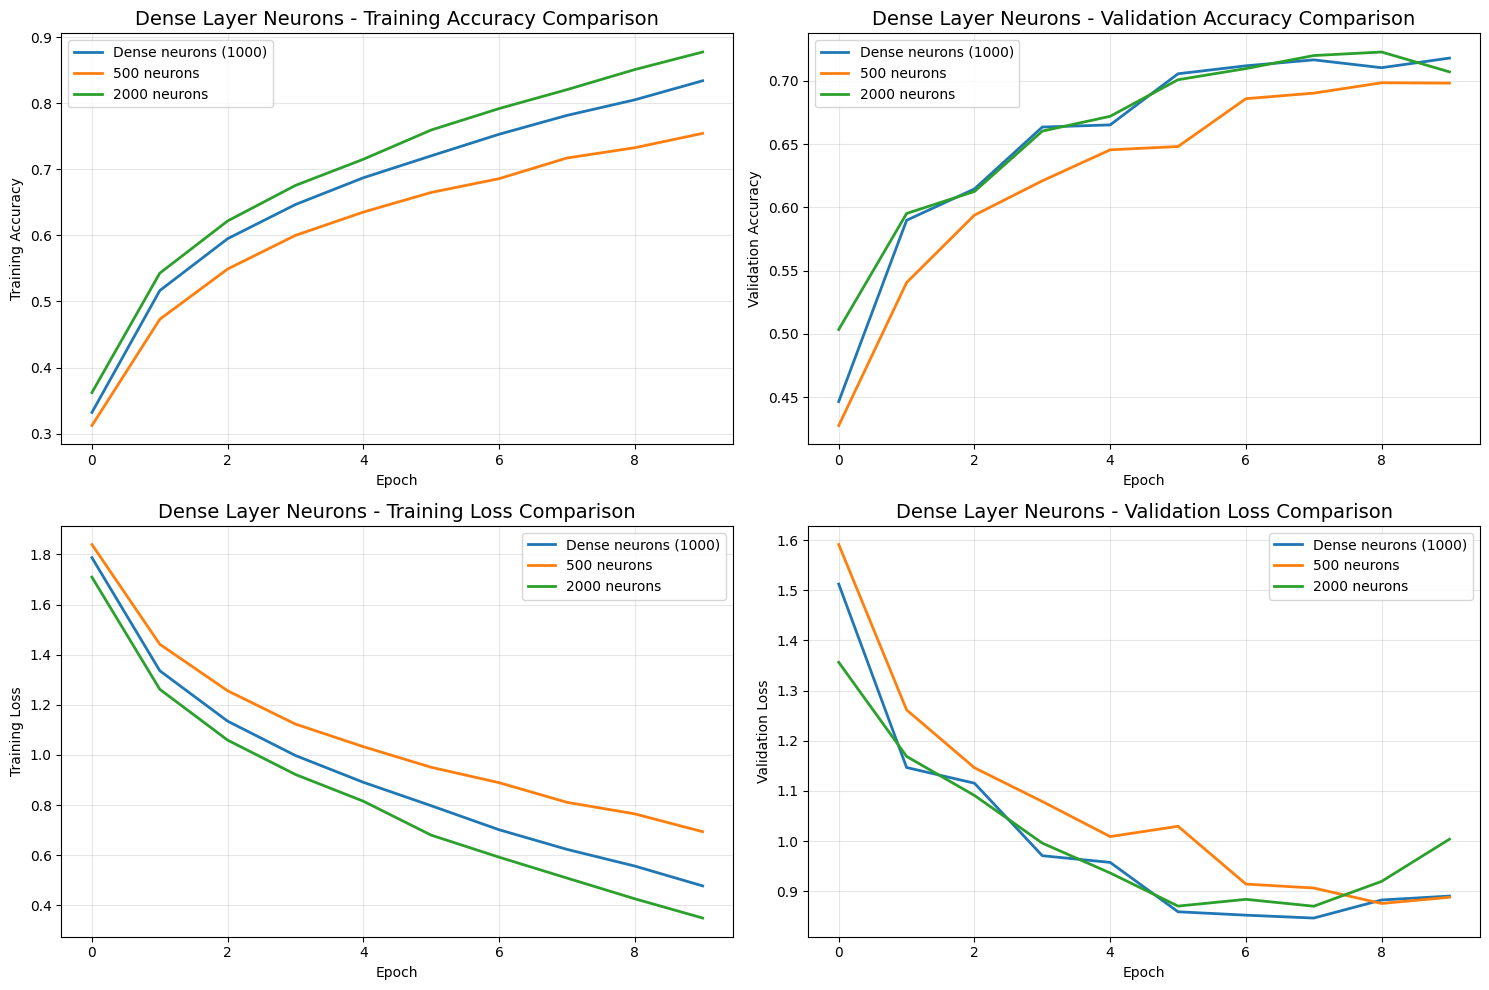

In [23]:
# 4. поміняти кількість нейронів в шарах багатошарового персептрона
# print("\n=== Experiment 4: Dense layer neurons ===")
models_dense = {'Dense neurons (1000)': all_histories['Default model']}

model_diff_dense1 = build_model(dense_neurons=500)
model_diff_dense1_history = model_diff_dense1.fit(x_train, y_train_one_hot, batch_size=256, epochs=10, validation_split=0.2, verbose=0)
# model_diff_dense1_history = model_diff_dense1.history
models_dense['500 neurons'] = {
    'accuracy': model_diff_dense1_history.history['accuracy'],
    'val_accuracy': model_diff_dense1_history.history['val_accuracy'],
    'loss': model_diff_dense1_history.history['loss'],
    'val_loss': model_diff_dense1_history.history['val_loss']
}

model_diff_dense2 = build_model(dense_neurons=2000)
model_diff_dense2_history = model_diff_dense2.fit(x_train, y_train_one_hot, batch_size=256, epochs=10, validation_split=0.2, verbose=0)
# model_diff_dense2_history = model_diff_dense2.history
models_dense['2000 neurons'] = {
    'accuracy': model_diff_dense2_history.history['accuracy'],
    'val_accuracy': model_diff_dense2_history.history['val_accuracy'],
    'loss': model_diff_dense2_history.history['loss'],
    'val_loss': model_diff_dense2_history.history['val_loss']
}

plot_parameter_comparison(models_dense, 'Dense Layer Neurons')


In [24]:
print('Test accuracy (dense neurons 500):', model_diff_dense1.evaluate(x_test, y_test_one_hot)[1])
print('Test accuracy (dense neurons 2000):', model_diff_dense2.evaluate(x_test, y_test_one_hot)[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6900 - loss: 0.8929
Test accuracy (dense neurons 500): 0.6899999976158142
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6984 - loss: 1.0416
Test accuracy (dense neurons 2000): 0.6984000205993652


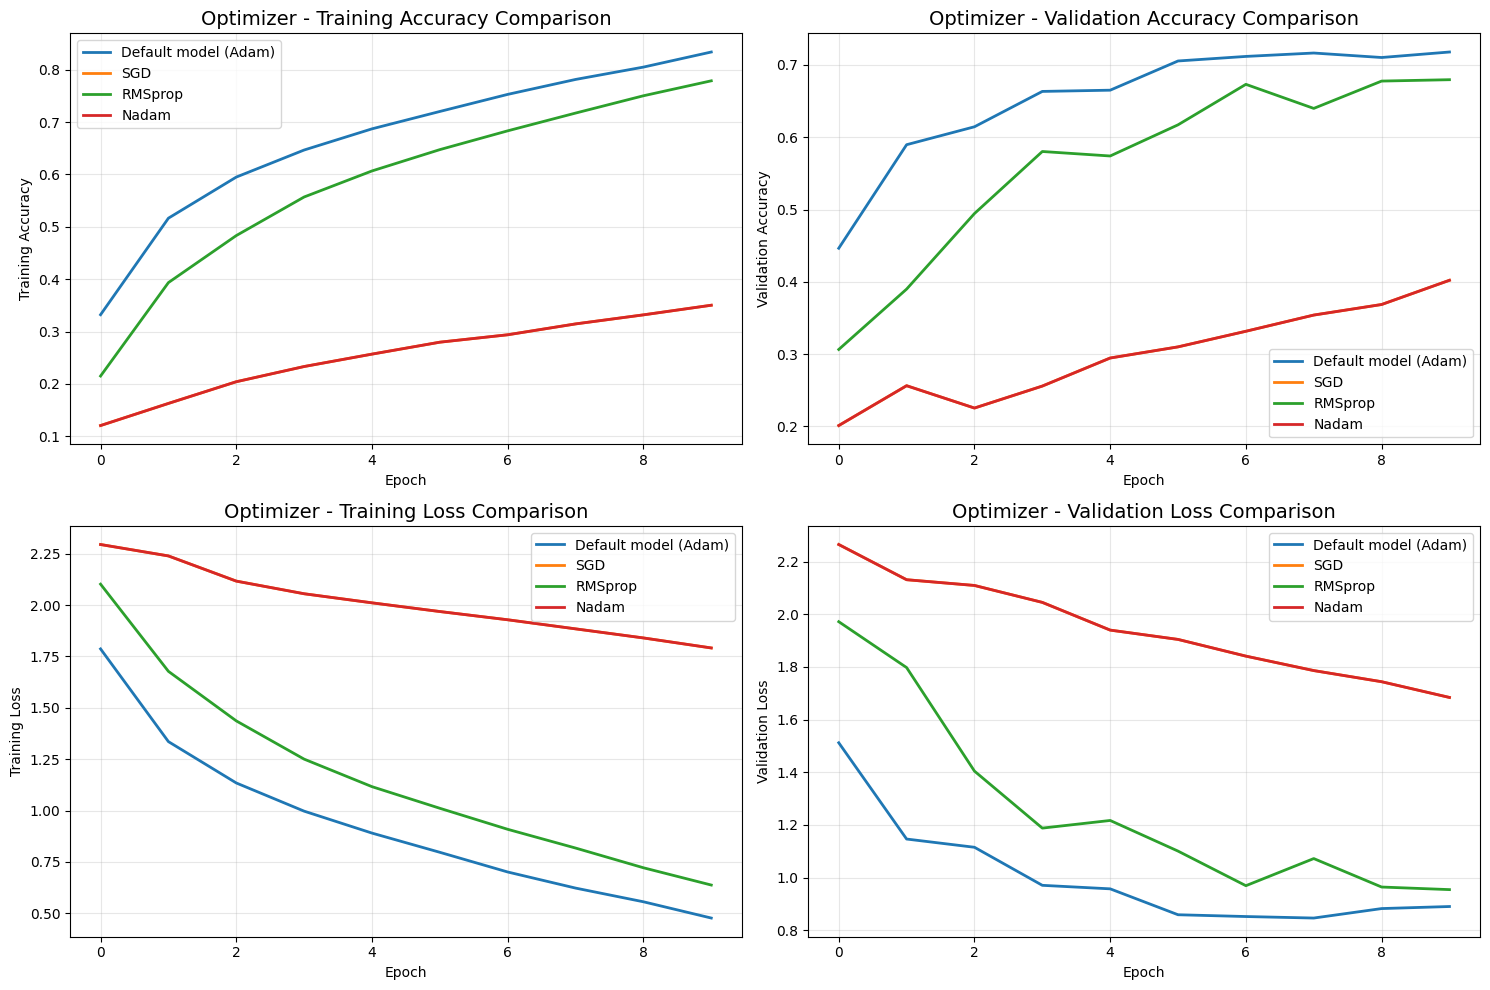

In [56]:
# 5. змінити алгоритм навчання
# print("\n=== Experiment 5: Optimizer ===")
models_optimizer = {'Default model (Adam)': all_histories['Default model']}

model_diff_opt1 = build_model(optimizer='sgd')
model_diff_opt1_history = model_diff_opt1.fit(x_train, y_train_one_hot, batch_size=256, epochs=10, validation_split=0.2, verbose=0)
# model_diff_opt1_history = model_diff_opt1.history
models_optimizer['SGD'] = {
    'accuracy': model_diff_opt1_history.history['accuracy'],
    'val_accuracy': model_diff_opt1_history.history['val_accuracy'],
    'loss': model_diff_opt1_history.history['loss'],
    'val_loss': model_diff_opt1_history.history['val_loss']
}

model_diff_opt2 = build_model(optimizer='rmsprop')
model_diff_opt2_history = model_diff_opt2.fit(x_train, y_train_one_hot, batch_size=256, epochs=10, validation_split=0.2, verbose=0)
# model_diff_opt2_history = model_diff_opt2.history
models_optimizer['RMSprop'] = {
    'accuracy': model_diff_opt2_history.history['accuracy'],
    'val_accuracy': model_diff_opt2_history.history['val_accuracy'],
    'loss': model_diff_opt2_history.history['loss'],
    'val_loss': model_diff_opt2_history.history['val_loss']
}

model_diff_opt3 = build_model(optimizer='nadam')
model_diff_opt3_history = model_diff_opt3.fit(x_train, y_train_one_hot, batch_size=256, epochs=10, validation_split=0.2, verbose=0)
# model_diff_opt3_history = model_diff_opt3.history
models_optimizer['Nadam'] = {
    'accuracy': model_diff_opt1_history.history['accuracy'],
    'val_accuracy': model_diff_opt1_history.history['val_accuracy'],
    'loss': model_diff_opt1_history.history['loss'],
    'val_loss': model_diff_opt1_history.history['val_loss']
}

plot_parameter_comparison(models_optimizer, 'Optimizer')



In [57]:
print('Test accuracy (SGD):', model_diff_opt1.evaluate(x_test, y_test_one_hot)[1])
print('Test accuracy (RMSProp):', model_diff_opt2.evaluate(x_test, y_test_one_hot)[1])
print('Test accuracy (Nadam):', model_diff_opt3.evaluate(x_test, y_test_one_hot)[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4068 - loss: 1.6604
Test accuracy (SGD): 0.4068000018596649
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6727 - loss: 0.9768
Test accuracy (RMSProp): 0.6726999878883362
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7209 - loss: 0.9330
Test accuracy (Nadam): 0.7208999991416931


In [27]:
the_model = build_model(conv_kernel=(3,3), dense_neurons=1500)
the_model_history = the_model.fit(x_train, y_train_one_hot, batch_size=256, epochs=10, validation_split=0.2, verbose=0)

print('Test accuracy (experimental):', the_model.evaluate(x_test, y_test_one_hot)[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7218 - loss: 0.9175
Test accuracy (experimental): 0.7218000292778015


In [28]:
the_model2 = build_model(conv_kernel=(3,3), dense_neurons=2000)
the_model2_history = the_model2.fit(x_train, y_train_one_hot, batch_size=256, epochs=10, validation_split=0.2, verbose=0)

print('Test accuracy (experimental2):', the_model2.evaluate(x_test, y_test_one_hot)[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7227 - loss: 0.9634
Test accuracy (experimental2): 0.7226999998092651


In [29]:
the_model3 = build_model(conv_kernel=(3,3), dense_neurons=500, dropout_rate=0.0)
the_model3_history = the_model3.fit(x_train, y_train_one_hot, batch_size=256, epochs=10, validation_split=0.2, verbose=0)

print('Test accuracy (experimental3):', the_model3.evaluate(x_test, y_test_one_hot)[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7026 - loss: 1.0580
Test accuracy (experimental3): 0.7026000022888184


In [13]:
datagen = ImageDataGenerator(
    horizontal_flip=True,
)

In [14]:
# datagen = ImageDataGenerator(
#             featurewise_center=False,  # set input mean to 0 over the dataset
#             samplewise_center=False,  # set each sample mean to 0
#             featurewise_std_normalization=False,  # divide inputs by std of the dataset
#             samplewise_std_normalization=False,  # divide each input by its std
#             zca_whitening=False,  # dimension reduction
#             rotation_range=0.5,  # randomly rotate images in the range 5 degrees
#             zoom_range=0.5,  # Randomly zoom image 5%
#             width_shift_range=0.5,  # randomly shift images horizontally 5%
#             height_shift_range=0.5,  # randomly shift images vertically 5%
#             horizontal_flip=False,  # randomly flip images
#             vertical_flip=False) # randomly flip images
# datagen = ImageDataGenerator(
#     # Spatial transformations
#     # rotation_range=15,        # Moderate rotation (CIFAR-10 objects aren't always upright)
#     # width_shift_range=0.1,    # 10% horizontal shift (CIFAR-10 images are small)
#     # height_shift_range=0.1,   # 10% vertical shift
#     horizontal_flip=True,     # Many CIFAR-10 objects are symmetric
#     # vertical_flip=False,      # Avoid flipping cats/dogs upside down!
#     #
#     # # Zoom and shear
#     # zoom_range=0.1,           # 10% zoom range
#     # shear_range=10,           # Small shear transformation
#     #
#     # # Fill mode for edge handling
#     # fill_mode='nearest'       # Good default for small datasets
# )

datagen.fit(x_train)
# Fit the model
the_model4 = build_model(conv_kernel=(3,3))
the_model4_history = the_model4.fit(
    datagen.flow(x_train, y_train_one_hot, batch_size=256),
    epochs=10,
    validation_data=(x_test, y_test_one_hot),
    verbose=0)

print('Test accuracy (experimental4):', the_model4.evaluate(x_test, y_test_one_hot)[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7459 - loss: 0.7354
Test accuracy (experimental4): 0.7458999752998352


In [15]:
the_model5 = build_model()
the_model5_history = the_model5.fit(
    datagen.flow(x_train, y_train_one_hot, batch_size=256),
    epochs=10,
    validation_data=(x_test, y_test_one_hot),
    verbose=0)

print('Test accuracy (experimental5):', the_model5.evaluate(x_test, y_test_one_hot)[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7433 - loss: 0.7455
Test accuracy (experimental5): 0.7433000206947327


In [77]:
the_model6 = build_model(conv_kernel=(3,3))
the_model6_history = the_model6.fit(
    datagen.flow(x_train, y_train_one_hot, batch_size=256),
    epochs=10,
    validation_data=(x_test, y_test_one_hot),
    verbose=0)

print('Test accuracy (experimental6):', the_model6.evaluate(x_test, y_test_one_hot)[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7526 - loss: 0.7354
Test accuracy (experimental6): 0.7526000142097473


In [17]:
datagen1 = ImageDataGenerator(
    # Spatial transformations
    # rotation_range=15,        # Moderate rotation (CIFAR-10 objects aren't always upright)
    width_shift_range=0.05,    # 10% horizontal shift (CIFAR-10 images are small)
    height_shift_range=0.05,   # 10% vertical shift
    horizontal_flip=True,     # Many CIFAR-10 objects are symmetric
    # vertical_flip=False,      # Avoid flipping cats/dogs upside down!
    #
    # # Zoom and shear
    # zoom_range=0.1,           # 10% zoom range
    # shear_range=10,           # Small shear transformation
    #
    # # Fill mode for edge handling
    # fill_mode='nearest'       # Good default for small datasets
)

In [18]:
the_model9 = build_model(conv_kernel=(4,4))
the_model9_history = the_model9.fit(
    datagen1.flow(x_train, y_train_one_hot, batch_size=256),
    epochs=10,
    validation_data=(x_test, y_test_one_hot),
    verbose=0)

print('Test accuracy (experimental8):', the_model9.evaluate(x_test, y_test_one_hot)[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7202 - loss: 0.8090
Test accuracy (experimental8): 0.7202000021934509


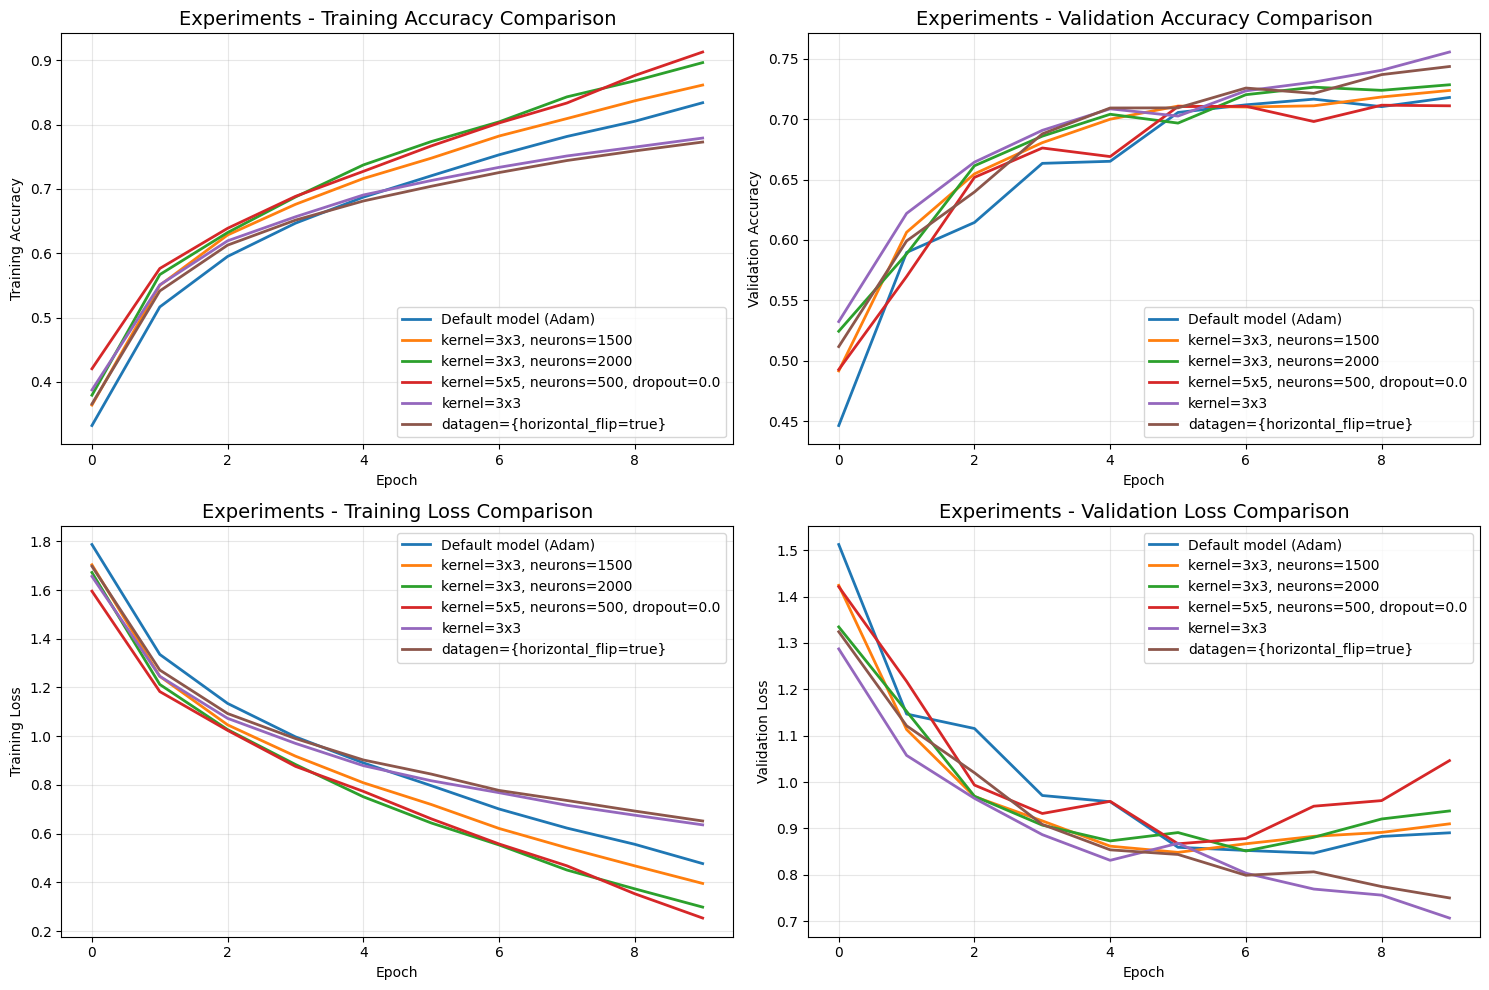

In [73]:
models_experimental = {'Default model': all_histories['Default model']}

models_experimental['kernel=3x3, neurons=1500'] = {
    'accuracy': the_model_history.history['accuracy'],
    'val_accuracy': the_model_history.history['val_accuracy'],
    'loss': the_model_history.history['loss'],
    'val_loss': the_model_history.history['val_loss']
}

models_experimental['kernel=3x3, neurons=2000'] = {
    'accuracy': the_model2_history.history['accuracy'],
    'val_accuracy': the_model2_history.history['val_accuracy'],
    'loss': the_model2_history.history['loss'],
    'val_loss': the_model2_history.history['val_loss']
}

models_experimental['kernel=5x5, neurons=500, dropout=0.0'] = {
    'accuracy': the_model3_history.history['accuracy'],
    'val_accuracy': the_model3_history.history['val_accuracy'],
    'loss': the_model3_history.history['loss'],
    'val_loss': the_model3_history.history['val_loss']
}

models_experimental['kernel=3x3'] = {
    'accuracy': the_model4_history.history['accuracy'],
    'val_accuracy': the_model4_history.history['val_accuracy'],
    'loss': the_model4_history.history['loss'],
    'val_loss': the_model4_history.history['val_loss']
}

models_experimental['datagen={horizontal_flip=true}'] = {
    'accuracy': the_model5_history.history['accuracy'],
    'val_accuracy': the_model5_history.history['val_accuracy'],
    'loss': the_model5_history.history['loss'],
    'val_loss': the_model5_history.history['val_loss']
}

plot_parameter_comparison(models_experimental, 'Experiments')

In [16]:
# Load the data
new_image = plt.imread("../data/lab3/cat.png")
# Read in the image(3, 14, 20)

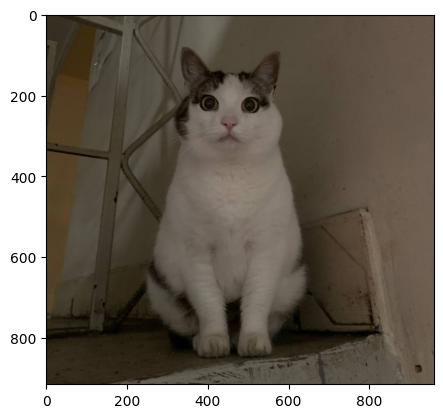

In [17]:
img = plt.imshow(new_image)

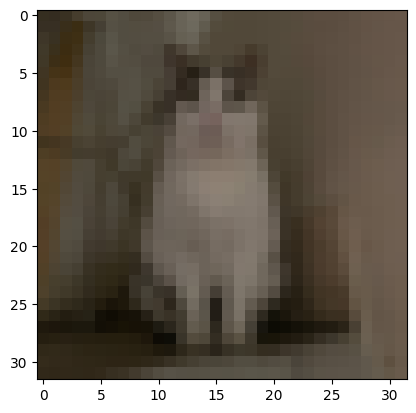

In [18]:
resized_image = resize(new_image, (32, 32, 3))
img = plt.imshow(resized_image)

In [19]:
predictions_experimental = the_model5.predict(np.array([resized_image]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


In [20]:
predictions_experimental

array([[0.00080076, 0.0006769 , 0.04929281, 0.48235145, 0.01114285,
        0.39099306, 0.02428616, 0.03655065, 0.00059414, 0.00331114]],
      dtype=float32)

In [21]:
list_index = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
x = predictions_experimental
for i in range(10):
    for j in range(10):
        if x[0][list_index[i]] > x[0][list_index[j]]:
            temp = list_index[i]
            list_index[i] = list_index[j]
            list_index[j] = temp  # Show the sorted labels in order from highest probability to lowest
print(list_index)

[3, 5, 2, 7, 6, 4, 9, 0, 1, 8]


In [22]:
i = 0
for i in range(5):
    print(classification[list_index[i]], ':', round(predictions_experimental[0][list_index[i]] * 100, 2), '%')

cat : 48.24 %
dog : 39.1 %
bird : 4.93 %
horse : 3.66 %
frog : 2.43 %


In [23]:
predictions_default = default_model.predict(np.array([resized_image]))
list_index = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
x = predictions_default
for i in range(10):
    for j in range(10):
        if x[0][list_index[i]] > x[0][list_index[j]]:
            temp = list_index[i]
            list_index[i] = list_index[j]
            list_index[j] = temp  #Show the sorted labels in order from highest probability to lowest
print(list_index)
i = 0
for i in range(5):
    print(classification[list_index[i]], ':', round(predictions_default[0][list_index[i]] * 100, 2), '%')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
[2, 5, 3, 6, 7, 4, 9, 1, 8, 0]
bird : 37.99 %
dog : 29.35 %
cat : 20.59 %
frog : 8.45 %
horse : 1.78 %


In [24]:
def predict_img(image_path, model):
    # Load the data
    new_image = plt.imread(image_path)
    # Read in the image(3, 14, 20)
    img = plt.imshow(new_image)
    resized_image = resize(new_image, (32, 32, 3))
    img = plt.imshow(resized_image)
    predictions = model.predict(np.array([resized_image]))
    # predictions
    list_index = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
    x = predictions
    for i in range(10):
        for j in range(10):
            if x[0][list_index[i]] > x[0][list_index[j]]:
                temp = list_index[i]
                list_index[i] = list_index[j]
                list_index[j] = temp  #Show the sorted labels in order from highest probability to lowest
    # print(list_index)
    i = 0
    for i in range(5):
        print(classification[list_index[i]], ':', round(predictions[0][list_index[i]] * 100, 2), '%')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
bird : 37.99 %
dog : 29.35 %
cat : 20.59 %
frog : 8.45 %
horse : 1.78 %


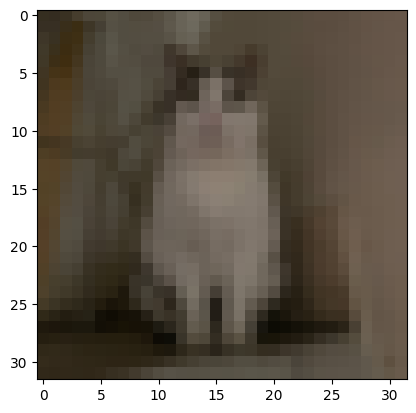

In [25]:
predict_img(image_path="../data/lab3/cat.png", model=default_model)

..\data\lab3\airplane.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
airplane : 99.95 %
bird : 0.05 %
ship : 0.0 %
deer : 0.0 %
truck : 0.0 %
..\data\lab3\automobile.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
automobile : 99.98 %
truck : 0.02 %
ship : 0.0 %
airplane : 0.0 %
bird : 0.0 %
..\data\lab3\bird.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
bird : 92.89 %
frog : 2.21 %
airplane : 2.03 %
dog : 0.91 %
cat : 0.71 %
..\data\lab3\cat.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
bird : 37.99 %
dog : 29.35 %
cat : 20.59 %
frog : 8.45 %
horse : 1.78 %
..\data\lab3\cat2.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
cat : 67.34 %
frog : 15.42 %
dog : 6.53 %
bird : 4.58 %
automobile : 1.81 %
..\data\lab3\deer.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
cat : 28.32 %
frog : 26.52 %
deer : 21.14 %
dog : 10.52 %
bird : 8.83 %
..\data\lab3\dog.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
bird : 91.29 %
cat : 3.63 %
dog : 2.45 %
frog : 1.23 %
airplane : 0.86 %
..\data\lab3\frog.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms

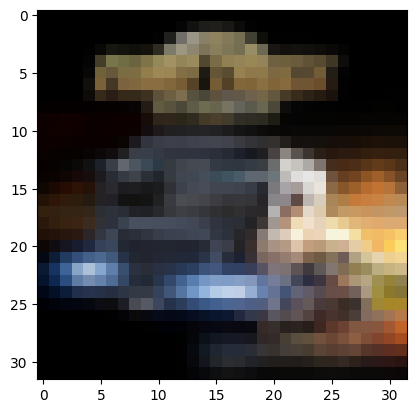

In [26]:
from pathlib import Path

img_directory = Path("../data/lab3")

for image_path in img_directory.iterdir():
    if image_path.is_file():
        print(image_path)
        predict_img(image_path=image_path, model=default_model)


..\data\lab3\airplane.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
airplane : 99.66 %
bird : 0.3 %
ship : 0.03 %
deer : 0.01 %
cat : 0.0 %
..\data\lab3\automobile.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
automobile : 99.99 %
truck : 0.01 %
ship : 0.0 %
airplane : 0.0 %
frog : 0.0 %
..\data\lab3\bird.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
bird : 91.83 %
frog : 7.27 %
cat : 0.4 %
dog : 0.39 %
deer : 0.09 %
..\data\lab3\cat.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
dog : 42.86 %
cat : 35.21 %
bird : 9.31 %
horse : 4.55 %
deer : 4.01 %
..\data\lab3\cat2.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
cat : 87.83 %
dog : 6.65 %
frog : 1.7 %
bird : 1.68 %
deer : 1.5 %
..\data\lab3\deer.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
frog : 83.93 %
deer : 6.13 %
cat : 5.2 %
bird : 3.54 %
dog : 0.87 %
..\data\lab3\dog.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
bird : 88.54 %
horse : 4.41 %
dog : 3.31 %
airplane : 1.61 %
cat : 1.13 %
..\data\lab3\frog.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
frog : 99.59 

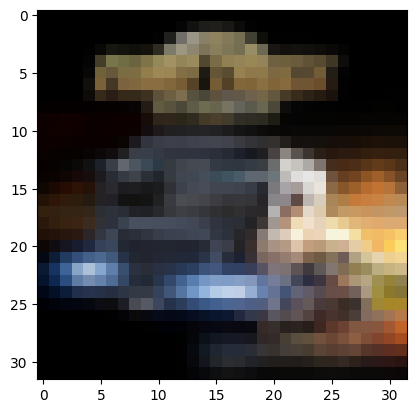

In [27]:
for image_path in img_directory.iterdir():
    if image_path.is_file():
        print(image_path)
        predict_img(image_path=image_path, model=the_model4)

In [32]:
datagen = ImageDataGenerator(
   horizontal_flip=True,     # Many CIFAR-10 objects are symmetric
)

experimental_model = Sequential([
    Input(shape=(32, 32, 3)),

    # Block 1
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.2),

    # Block 2
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.3),

    # Block 3
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.4),

    # Head
    GlobalAveragePooling2D(),       # replaces Flatten + big Dense
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

experimental_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Fit the model
# experimental_model = build_model(conv_kernel=(3,3))
experimental_model_history = experimental_model.fit(
    datagen.flow(x_train, y_train_one_hot, batch_size=256),
    epochs=10,
    validation_data=(x_test, y_test_one_hot),
    verbose=0)

print('Test accuracy (experimental architecture):', experimental_model.evaluate(x_test, y_test_one_hot)[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7653 - loss: 0.6967
Test accuracy (experimental architecture): 0.7652999758720398


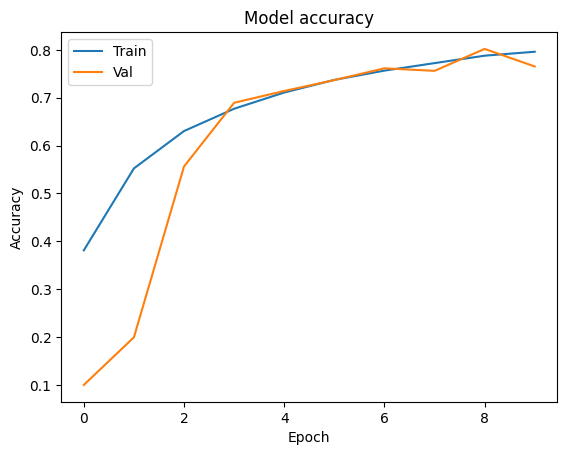

Best validation accuracy: 0.8019000291824341
Best training accuracy: 0.796019971370697


In [33]:
# Visualize the models accuracy
plt.plot(experimental_model_history.history['accuracy'])
plt.plot(experimental_model_history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

best_val_acc = max(experimental_model_history.history['val_accuracy'])
# best_val_epoch = np.argmax(hist.history['val_accuracy'])

best_train_acc = max(experimental_model_history.history['accuracy'])
# best_train_epoch = np.argmax(hist.history['accuracy'])

print('Best validation accuracy:', best_val_acc)
print('Best training accuracy:', best_train_acc)

In [51]:
# the_model4 = build_model(conv_kernel=(3,3))
# the_model4_history = the_model4.fit(
#     datagen.flow(x_train, y_train_one_hot, batch_size=256),
#     epochs=10,
#     validation_data=(x_test, y_test_one_hot),
#     verbose=0)

experimental_model3 = Sequential([
    # Input(shape=(32, 32, 3)),
    #
    # Conv2D(64, (3, 3), padding='same', activation='relu'),
    # BatchNormalization(),
    # Conv2D(64, (3, 3), padding='same', activation='relu'),
    # BatchNormalization(),
    # MaxPooling2D(2, 2),
    # Dropout(0.5),
    #
    # Conv2D(128, (3, 3), padding='same', activation='relu'),
    # BatchNormalization(),
    # Conv2D(128, (3, 3), padding='same', activation='relu'),
    # BatchNormalization(),
    # MaxPooling2D(2, 2),
    # Dropout(0.5),
    #
    # GlobalAveragePooling2D(),       # replaces Flatten + big Dense
    # Dense(256, activation='relu'),
    # BatchNormalization(),
    # Dropout(0.5),
    # Dense(10, activation='softmax'),

    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),

    Dense(1000, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(500, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(250, activation='relu'),
    BatchNormalization(),
    Dense(10, activation='softmax')
])

experimental_model3.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


# Fit the model
# experimental_model = build_model(conv_kernel=(3,3))
experimental_model3_history = experimental_model3.fit(
    datagen.flow(x_train, y_train_one_hot, batch_size=256),
    epochs=10,
    validation_data=(x_test, y_test_one_hot),
    verbose=0)

print('Test accuracy (experimental architecture3):', experimental_model3.evaluate(x_test, y_test_one_hot)[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7363 - loss: 0.8059
Test accuracy (experimental architecture3): 0.736299991607666


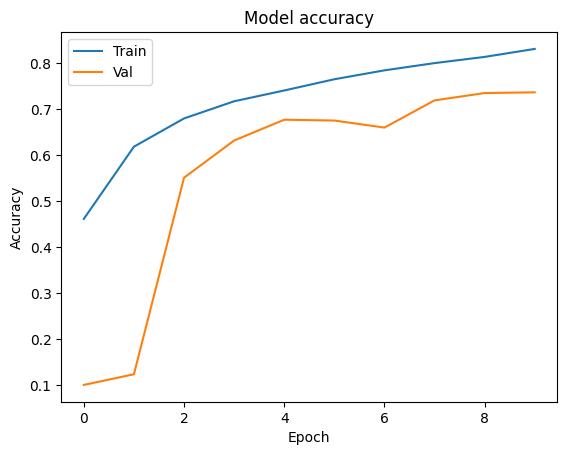

Best validation accuracy: 0.736299991607666
Best training accuracy: 0.8307200074195862


In [52]:
# Visualize the models accuracy
plt.plot(experimental_model3_history.history['accuracy'])
plt.plot(experimental_model3_history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

best_val_acc = max(experimental_model3_history.history['val_accuracy'])
# best_val_epoch = np.argmax(hist.history['val_accuracy'])

best_train_acc = max(experimental_model3_history.history['accuracy'])
# best_train_epoch = np.argmax(hist.history['accuracy'])

print('Best validation accuracy:', best_val_acc)
print('Best training accuracy:', best_train_acc)

In [28]:
experimental_model4 = Sequential([

    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(1000, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(500, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(250, activation='relu'),
    BatchNormalization(),
    Dense(10, activation='softmax')
])

experimental_model4.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


# Fit the model
experimental_model4_history = experimental_model4.fit(
    datagen.flow(x_train, y_train_one_hot, batch_size=256),
    epochs=10,
    validation_data=(x_test, y_test_one_hot),
    verbose=0)

print('Test accuracy (experimental architecture4):', experimental_model4.evaluate(x_test, y_test_one_hot)[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.7885 - loss: 0.6461
Test accuracy (experimental architecture4): 0.7885000109672546


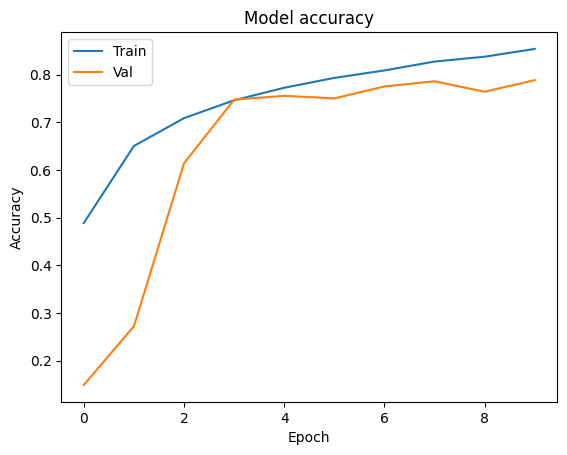

Best validation accuracy: 0.7885000109672546
Best training accuracy: 0.8539400100708008


In [29]:
# Visualize the models accuracy
plt.plot(experimental_model4_history.history['accuracy'])
plt.plot(experimental_model4_history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

best_val_acc = max(experimental_model4_history.history['val_accuracy'])
# best_val_epoch = np.argmax(hist.history['val_accuracy'])

best_train_acc = max(experimental_model4_history.history['accuracy'])
# best_train_epoch = np.argmax(hist.history['accuracy'])

print('Best validation accuracy:', best_val_acc)
print('Best training accuracy:', best_train_acc)

..\data\lab3\airplane.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
airplane : 99.98 %
bird : 0.02 %
ship : 0.0 %
truck : 0.0 %
deer : 0.0 %
..\data\lab3\automobile.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
automobile : 100.0 %
truck : 0.0 %
ship : 0.0 %
frog : 0.0 %
airplane : 0.0 %
..\data\lab3\bird.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
bird : 96.38 %
frog : 3.5 %
dog : 0.05 %
cat : 0.04 %
deer : 0.02 %
..\data\lab3\cat.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
cat : 83.47 %
dog : 10.71 %
bird : 3.17 %
frog : 0.92 %
horse : 0.82 %
..\data\lab3\cat2.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
cat : 83.0 %
frog : 11.54 %
dog : 3.62 %
bird : 1.04 %
deer : 0.37 %
..\data\lab3\deer.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
frog : 55.95 %
cat : 23.52 %
deer : 18.23 %
bird : 1.27 %
dog : 0.45 %
..\data\lab3\dog.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
horse : 85.82 %
deer : 11.62 %
bird : 1.7 %
dog : 0.7 %
cat : 0.15 %
..\data\lab3\frog.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
frog : 99.36

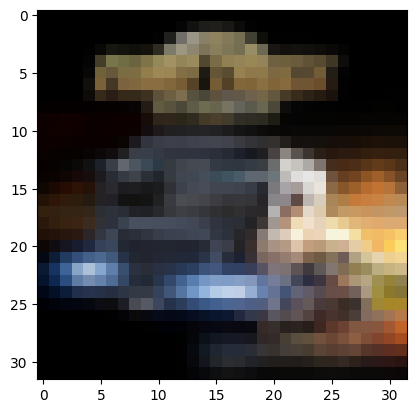

In [30]:
for image_path in img_directory.iterdir():
    if image_path.is_file():
        print(image_path)
        predict_img(image_path=image_path, model=experimental_model4)

..\data\lab3\airplane.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
airplane : 99.98 %
bird : 0.02 %
ship : 0.0 %
deer : 0.0 %
truck : 0.0 %
..\data\lab3\automobile.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
automobile : 99.95 %
truck : 0.05 %
ship : 0.0 %
airplane : 0.0 %
frog : 0.0 %
..\data\lab3\bird.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
bird : 99.31 %
frog : 0.35 %
airplane : 0.13 %
deer : 0.1 %
cat : 0.07 %
..\data\lab3\cat.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
cat : 75.46 %
dog : 20.07 %
frog : 1.13 %
deer : 1.1 %
horse : 0.88 %
..\data\lab3\cat2.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
cat : 37.86 %
frog : 32.94 %
bird : 14.06 %
deer : 5.97 %
dog : 4.74 %
..\data\lab3\deer.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
deer : 53.66 %
frog : 20.84 %
cat : 19.1 %
bird : 2.24 %
airplane : 1.38 %
..\data\lab3\dog.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
bird : 34.19 %
deer : 25.98 %
dog : 15.87 %
horse : 13.54 %
airplane : 3.91 %
..\data\lab3\frog.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35

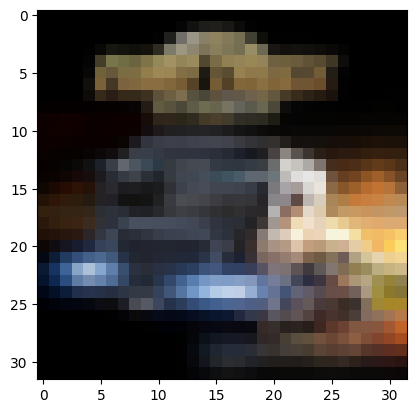

In [34]:
for image_path in img_directory.iterdir():
    if image_path.is_file():
        print(image_path)
        predict_img(image_path=image_path, model=experimental_model)